# 00 — Look at the signal before you analyse it

**Goal of this notebook:** put the actual per-channel signal on screen, with the task's
event triggers drawn on top of it, and browse it — the way you would open `raw.plot()` or
`epochs.plot()` in MNE before touching an analysis.

Everything in notebooks 02–04 is an *average*: PSTHs, tuning curves, decoding accuracy.
Averages are where the science is, but they are also where problems hide. A dead channel, a
saturating artefact, a trigger that lands 200 ms from where you think it does — none of
these announce themselves in a group mean. They just quietly bend the result.

So this notebook is numbered `00`: looking at the raw signal is what you do *first*.

---

## ⚠️ First, an honest word about what "raw" means here

**This dataset contains no raw voltage traces.** There are no 30 kHz waveforms, no LFP, no
spike snippets. By the time the data reached us the pipeline had already:

1. band-pass filtered 250–5000 Hz,
2. detected threshold crossings (and computed spike-band power),
3. **binned** them into 10–20 ms windows,
4. **smoothed** them,
5. dropped channels below 2 Hz.

Steps 3 and 4 are irreversible. So "raw" in this notebook means *the rawest thing the
dataset provides* — the per-channel binned rate time series. We are looking at a heavily
processed derivative of cortical activity, not at cortex. That is worth holding in mind
whenever a trace looks suspiciously smooth: it is smooth because someone smoothed it.

## Why this notebook uses two different files

MNE's `raw.plot` browses a *continuous* recording. The `fig1` files are **trialised**, and
they cannot be turned back into one:

- each epoch spans 2.98 s, from −1000 ms to +1980 ms around target onset,
- but the median trial lasts only 2.34 s, and each epoch starts a full second *before* its
  trial begins.

So consecutive epochs **overlap in real recording time**. Gluing them end to end would
produce a picture in which the x-axis is not time — a display fiction. We do not do that.

Instead we use each file for what it actually is:

| view | file | what it gives you |
|---|---|---|
| **`raw.plot`** | `fig5_T16_continuous.h5` | 239 s of genuinely unbroken recording, with real trigger times on the same clock |
| **`epochs.plot`** | `fig1_T16_delay.h5` | one trial at a time — the data the decoding actually runs on |
| **`epochs.plot_image`** | `fig1_T16_delay.h5` | every trial for one channel, grouped by direction |

> ### ⚠️ About the continuous file
> `fig5_T16_continuous.h5` is from a **different task** — closed-loop BCI cursor control
> driven by preparatory activity, not the open-loop instructed-delay task — and it is
> **preprocessed differently**: causal exponential smoothing (τ = 28–70 ms) instead of the
> acausal σ = 100 ms Gaussian, z-scored, and with no 2 Hz channel cut.
>
> It is here **to be looked at**. No number from it enters any result in this project.
> Its value is that it is the only place in the dataset where you can watch the signal and
> the task unfold together in real time.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, fixed

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src import plotting
from src.data_loading import load_continuous_data, load_trial_data
from src.preprocessing import direction_labels, pick_feature, select_trials, to_hz

np.random.seed(config.RANDOM_STATE)
plotting.use_house_style()
config.ensure_output_dirs()
print("ready")

ready


## 1. A genuinely continuous recording

Load it and look at what is actually there before plotting anything.

In [2]:
cont = load_continuous_data(config.PARTICIPANT, config.candidate_data_dirs())
print(cont)
print()
print(f"duration        : {cont.duration_s:.1f} s of unbroken {cont.bin_s * 1000:.0f} ms bins")
print(f"features        : {cont.n_features}  (all spike + spike-band-power channels)")
print(f"keep_chans      : {cont.keep_chans.size}  (the subset the online decoder used)")
print(f"units           : z-scored arbitrary units, causal exponential smoothing")

trials = cont.trials
n_trials = trials["start_time"].size
n_nogo = int(np.nansum(trials["no_go_bool"]))
print(f"\ntrials          : {n_trials}  ({n_nogo} no-go, {n_trials - n_nogo} go)")
print(f"go_cue_time NaN : {int(np.isnan(trials['go_cue_time']).sum())}  "
      f"(NaN exactly on the no-go trials - there was no go cue)")

gaps = (trials["start_time"][1:] - trials["end_time"][:-1]) / 1000
print(f"\ntrial duration  : median {np.median((trials['end_time'] - trials['start_time']) / 1000):.2f} s")
print(f"inter-trial gap : median {np.median(gaps):.2f} s   <- real dead time, "
      f"which the trialised fig1 files hide completely")

ContinuousData(T16: 11955 bins x 512 features, bin=20 ms, 239.1 s, 50 trials)

duration        : 239.1 s of unbroken 20 ms bins
features        : 512  (all spike + spike-band-power channels)
keep_chans      : 98  (the subset the online decoder used)
units           : z-scored arbitrary units, causal exponential smoothing

trials          : 50  (16 no-go, 34 go)
go_cue_time NaN : 16  (NaN exactly on the no-go trials - there was no go cue)

trial duration  : median 2.59 s
inter-trial gap : median 2.02 s   <- real dead time, which the trialised fig1 files hide completely


That last line is the first thing the continuous view buys us. In `fig1` every epoch begins
at −1000 ms and the recording appears to run continuously from trial to trial. In reality
there are ~2 s of dead time between trials where nothing task-related happens at all.

## 2. Building the browser inputs

Three things go into the browser: the **signals**, the **event triggers**, and the
**auxiliary channels** (MNE would call these misc/stim rows).

The event times in `trial_info` are on the same clock as `clock_time`, so no alignment
guesswork is needed — we just subtract the recording start so the axis begins at 0 s.

In [3]:
t_s = (cont.clock_ms - cont.clock_ms[0]) / 1000.0          # seconds from recording start

def to_seconds(ms):
    return (np.asarray(ms, dtype=float) - cont.clock_ms[0]) / 1000.0

events = {
    "trial start": to_seconds(trials["start_time"]),
    "go cue":      to_seconds(trials["go_cue_time"]),   # NaN on no-go: skipped automatically
    "trial end":   to_seconds(trials["end_time"]),
}

# Auxiliary rows: what the participant and the online decoder were doing.
cursor_speed = np.r_[0.0, np.linalg.norm(np.diff(cont.cursor, axis=0), axis=1)] / cont.bin_s
aux = {
    "cursor X": cont.cursor[:, 0],
    "cursor Y": cont.cursor[:, 1],
    "EMG 1": cont.emg[:, 0],
    "cursor speed": cursor_speed,
    "decoder move-state": cont.dec_move_state,
}

for name, times in events.items():
    finite = np.isfinite(times).sum()
    print(f"{name:12s}: {finite} events")
print(f"\naux rows: {list(aux)}")

trial start : 50 events
go cue      : 34 events
trial end   : 50 events

aux rows: ['cursor X', 'cursor Y', 'EMG 1', 'cursor speed', 'decoder move-state']


## 3. Dead channels — the reason `keep_chans` exists

Before browsing, one check that only ever happens if you look: **how many of these 512
features are flat lines?**

features with SD < 0.01 (flat)  : 268 / 512
features that vary              : 244
of the 98 keep_chans, how many are flat? 0


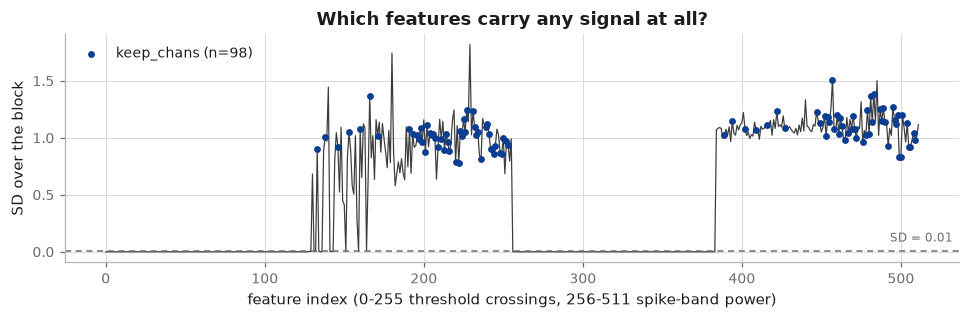

In [4]:
sds = cont.neural.std(axis=0)
dead = cont.dead_features(sd_threshold=0.01)

print(f"features with SD < 0.01 (flat)  : {dead.size} / {cont.n_features}")
print(f"features that vary              : {cont.n_features - dead.size}")
print(f"of the {cont.keep_chans.size} keep_chans, how many are flat? "
      f"{int(np.isin(cont.keep_chans, dead).sum())}")

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.plot(sds, color=plotting.TRACE_COLOR, lw=0.8)
ax.scatter(cont.keep_chans, sds[cont.keep_chans], s=12, color=plotting.ACCENT,
           zorder=4, label=f"keep_chans (n={cont.keep_chans.size})")
ax.axhline(0.01, color=plotting.INK_MUTED, ls=(0, (4, 3)), lw=1.0)
ax.annotate("SD = 0.01", xy=(1.0, 0.01), xycoords=("axes fraction", "data"),
            xytext=(-4, 4), textcoords="offset points", fontsize=8,
            color=plotting.INK_MUTED, ha="right", va="bottom")
ax.set_xlabel("feature index (0-255 threshold crossings, 256-511 spike-band power)")
ax.set_ylabel("SD over the block")
ax.set_title("Which features carry any signal at all?")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "continuous_channel_sd.png", bbox_inches="tight")
plt.show()

**More than half the features are flat**, and *every single* `keep_chans` feature is live.
That is not a coincidence — it is what `keep_chans` is for, and this plot is the evidence.

Electrodes fail, or sit in white matter, or never had a neuron near them. The array has
physical channels that were simply never useful. If you fed all 512 features to a decoder,
the flat ones would contribute nothing but would still be standardised — dividing a
constant by a near-zero standard deviation, which is exactly how you manufacture numerical
garbage. Notebooks 02–04 use `fig1`, which already had this cut applied for us; here we can
see what was cut.

So the browser defaults to the live subset.

In [5]:
live = cont.keep_chans[~np.isin(cont.keep_chans, dead)]
signals = cont.neural[:, live]
labels = [f"f{int(c)}" for c in live]
print(f"browsing {signals.shape[1]} live features")

browsing 98 live features


## 4. The raw browser

This is the `raw.plot` equivalent: channels stacked top to bottom, time along the x-axis,
event triggers as vertical rules, and the behavioural channels in a panel below.

Traces are drawn in a single neutral colour on purpose. With twenty overlapping series a
categorical palette encodes nothing — the y-position already identifies the channel — and
would only add noise. Colour is reserved for the three event types, which are also
distinguished by line style so they remain separable in greyscale or for a colour-blind
reader.

The `scale` argument is MNE's `scalings`: the vertical spacing between channels, in signal
units. The default separates the median channel; raise it if traces collide, lower it to
fit more channels on screen.

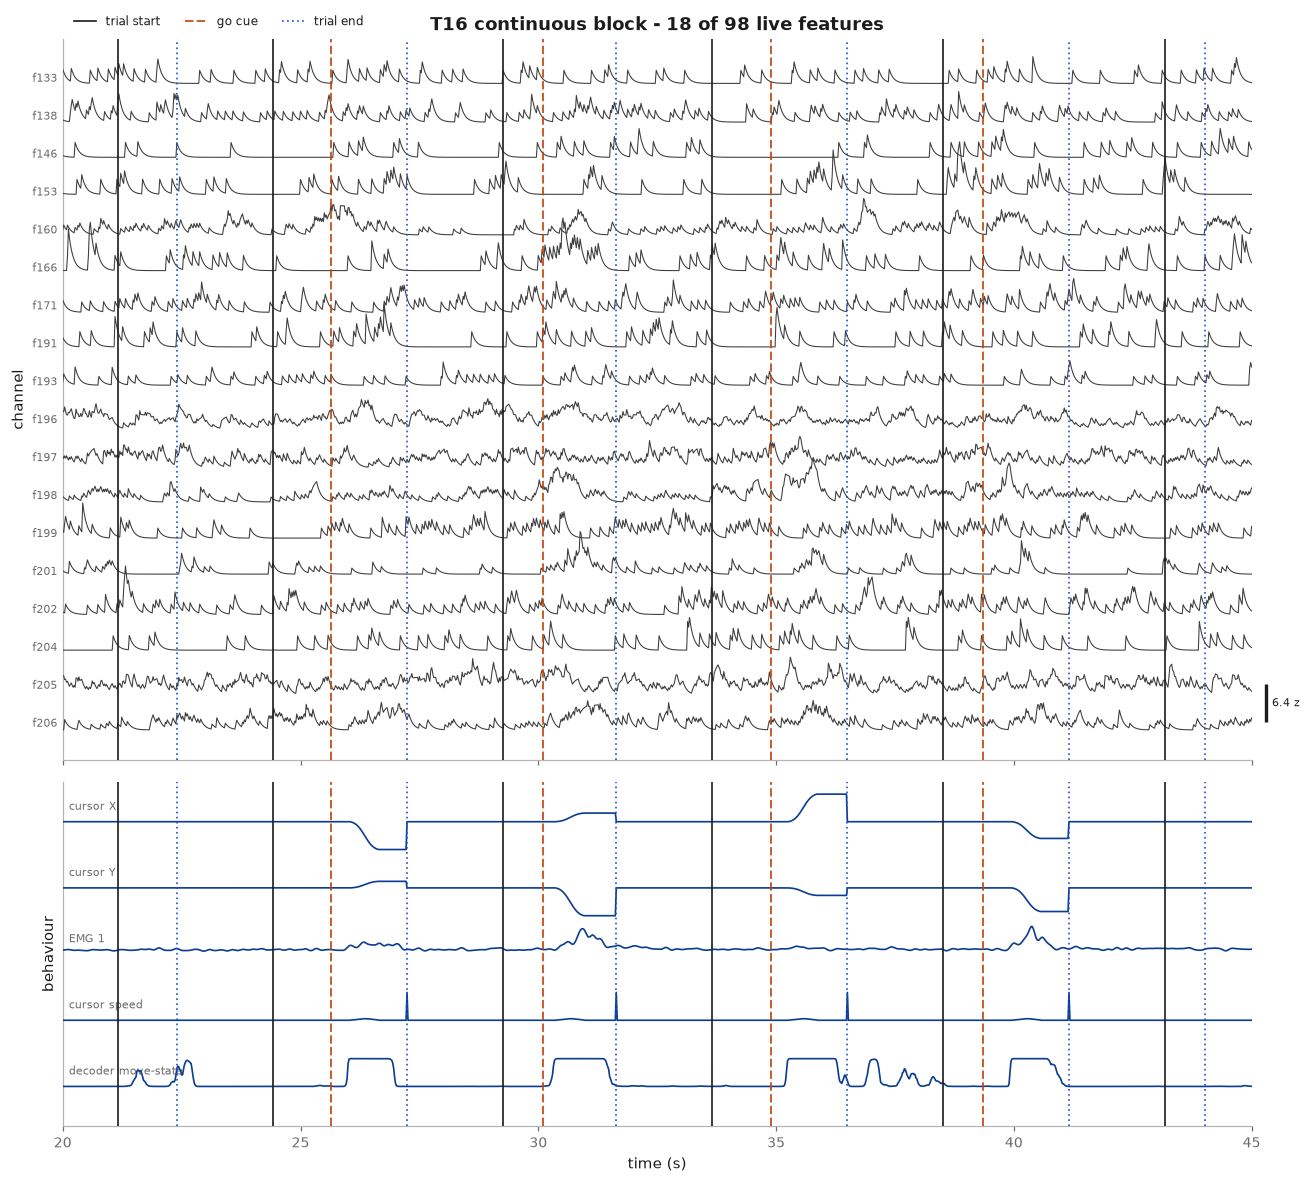

In [6]:
fig = plotting.plot_signal_browser(
    t_s, signals, labels,
    events=events, aux=aux,
    start_s=20.0, duration_s=25.0, n_channels=18,
    units="z",
    title=f"{config.PARTICIPANT} continuous block - 18 of {signals.shape[1]} live features",
)
fig.savefig(config.FIGURES_DIR / "raw_browser_continuous.png", bbox_inches="tight")
plt.show()

**What to look for, in order:**

1. **Do the triggers land where the signal changes?** The go cue (orange dashed) should be
   followed — not preceded — by EMG activity and then cursor motion. If a trigger sat in the
   middle of a movement, or after it, the alignment would be wrong and every result built
   on it would be wrong too.
2. **Trials without a go cue.** Some trials show a start and an end with no orange line
   between them. Those are the 16 no-go catch trials, and the cursor stays put through them.
3. **Do any channels look pathological?** Flat stretches, sudden steps, one channel
   dominating everything, traces clipping at a ceiling.
4. **Is there drift?** A slow wander across the whole block, unrelated to the task, is the
   block-specific drift that motivates grouping cross-validation folds by block in
   notebook 03.

## 5. Browse it interactively

Now the same figure with sliders. Drag the time slider to scan the whole 239 s, change how
many channels are shown, and adjust the vertical scale.

> **Note:** widget controls only work in a live kernel. The static figure above is rendered
> into the saved notebook so the analysis is readable without running anything.

In [7]:
def browse_continuous(start_s=20.0, duration_s=25.0, n_channels=18, scale=4.0):
    fig = plotting.plot_signal_browser(
        t_s, signals, labels, events=events, aux=aux,
        start_s=start_s, duration_s=duration_s,
        n_channels=n_channels, scale=scale, units="z",
        title=f"{config.PARTICIPANT} continuous - {start_s:.0f} to "
              f"{start_s + duration_s:.0f} s",
    )
    plt.show()

interact(
    browse_continuous,
    start_s=FloatSlider(min=0, max=max(0.0, float(t_s[-1]) - 5), step=1.0, value=20.0,
                        description="start (s)", continuous_update=False),
    duration_s=FloatSlider(min=5, max=60, step=5, value=25.0, description="window (s)",
                           continuous_update=False),
    n_channels=IntSlider(min=4, max=40, step=2, value=18, description="channels",
                         continuous_update=False),
    scale=FloatSlider(min=1.0, max=15.0, step=0.5, value=4.0, description="scale (z)",
                      continuous_update=False),
);

interactive(children=(FloatSlider(value=20.0, continuous_update=False, description='start (s)', max=234.08, st…

## 6. One trial, close up

Zooming to a single trial makes the sequence explicit: go cue → muscle activity → cursor
movement. This is the ordering that has to hold for the task to make sense, and here you
can confirm it by eye rather than assuming it.

trial 2: start 9.50s, go cue 10.72s, end 12.30s, delay 1.20s


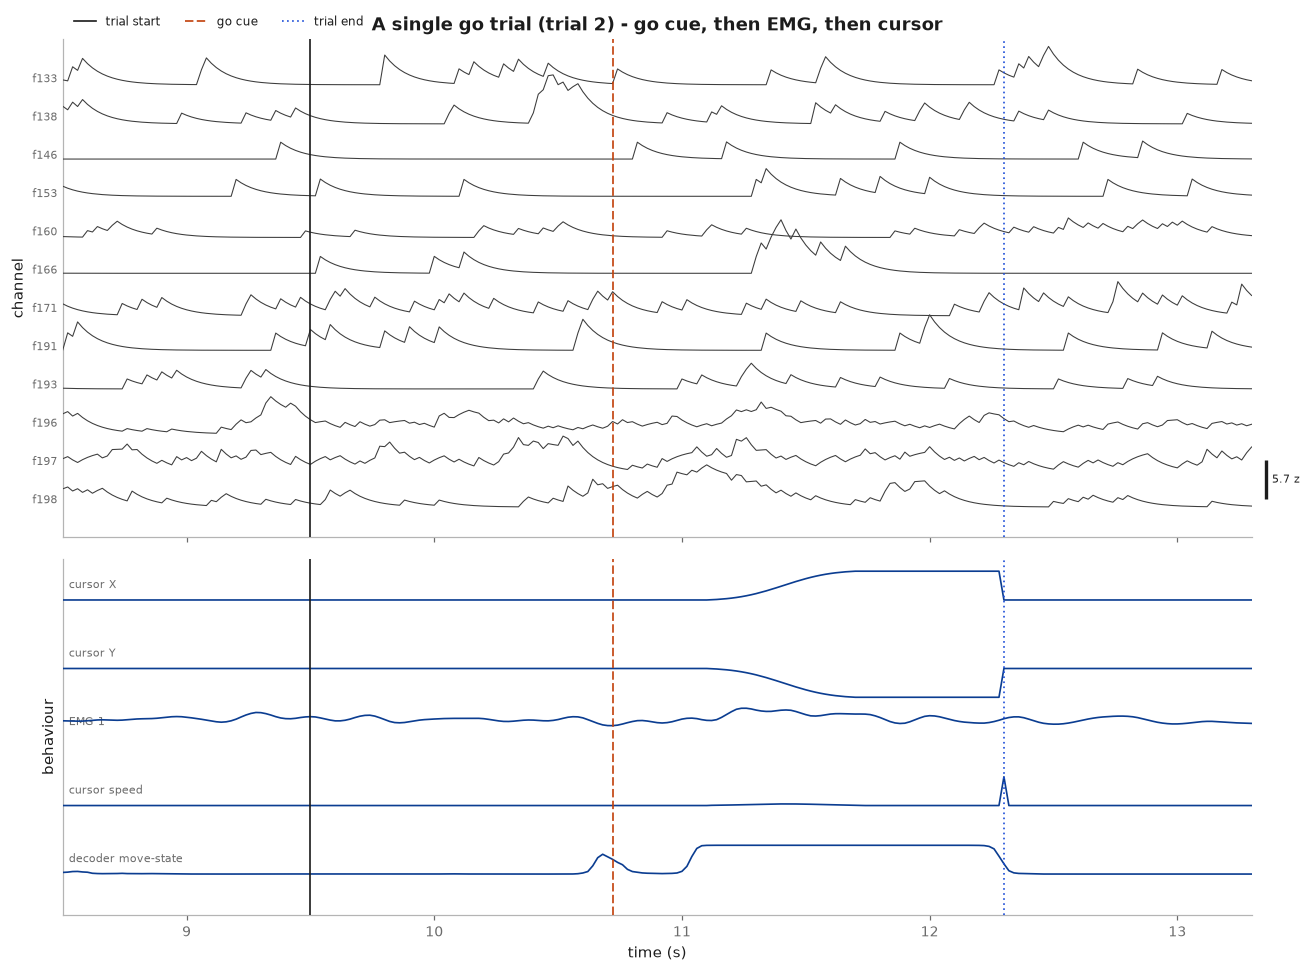

In [8]:
# Pick the first go trial that has a finite go cue, and frame it with a little padding.
go_trials = np.where(np.isfinite(trials["go_cue_time"]))[0]
tr = int(go_trials[2])
t0 = float(to_seconds(trials["start_time"][tr])) - 1.0
t1 = float(to_seconds(trials["end_time"][tr])) + 1.0

print(f"trial {tr}: start {to_seconds(trials['start_time'][tr]):.2f}s, "
      f"go cue {to_seconds(trials['go_cue_time'][tr]):.2f}s, "
      f"end {to_seconds(trials['end_time'][tr]):.2f}s, "
      f"delay {trials['delay_data'][tr] / 1000:.2f}s")

fig = plotting.plot_signal_browser(
    t_s, signals, labels, events=events, aux=aux,
    start_s=t0, duration_s=t1 - t0, n_channels=12, units="z",
    title=f"A single go trial (trial {tr}) - go cue, then EMG, then cursor",
)
fig.savefig(config.FIGURES_DIR / "raw_browser_single_trial.png", bbox_inches="tight")
plt.show()

## 7. Back to `fig1`: the epoch view

Now the file the analysis actually uses. Same stacked layout, but one trial at a time,
aligned to target onset at `t = 0`, and in **Hz** rather than z-scores.

Apply the standard trial selection first, so we are browsing exactly the trials the decoder
sees in notebook 03.

In [9]:
td = load_trial_data(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                     config.candidate_data_dirs())
features = pick_feature(td, config.FEATURE_TYPE)
keep, report = select_trials(features, td.delay, td.no_go,
                             config.MIN_DELAY_S, config.GO_TRIALS_ONLY)
print(report)

labels_all, centres = direction_labels(td.target, td.start, config.N_DIRECTIONS)

X_hz = to_hz(features[keep], td.bin_s)          # (trials, bins, channels) in Hz
y = labels_all[keep]
delays_ms = td.delay[keep] * 1000
cursor = td.cursor[keep]
emg = td.optional["emg_data_all"][keep] if "emg_data_all" in td.optional else None
ch_labels = [f"ch{int(c)}" for c in td.keep_chans]
go_cue_times_ms = sorted(np.unique(delays_ms).tolist())
print(f"\nbrowsing {X_hz.shape[0]} trials x {X_hz.shape[2]} channels, in Hz")

Trial selection
  starting trials              : 385
  dropped, non-finite features : 0
  dropped, non-finite delay    : 0
  dropped, delay < 0.8 s        : 0
  dropped, no-go trials        : 121
  --> kept                     : 264

browsing 264 trials x 61 channels, in Hz


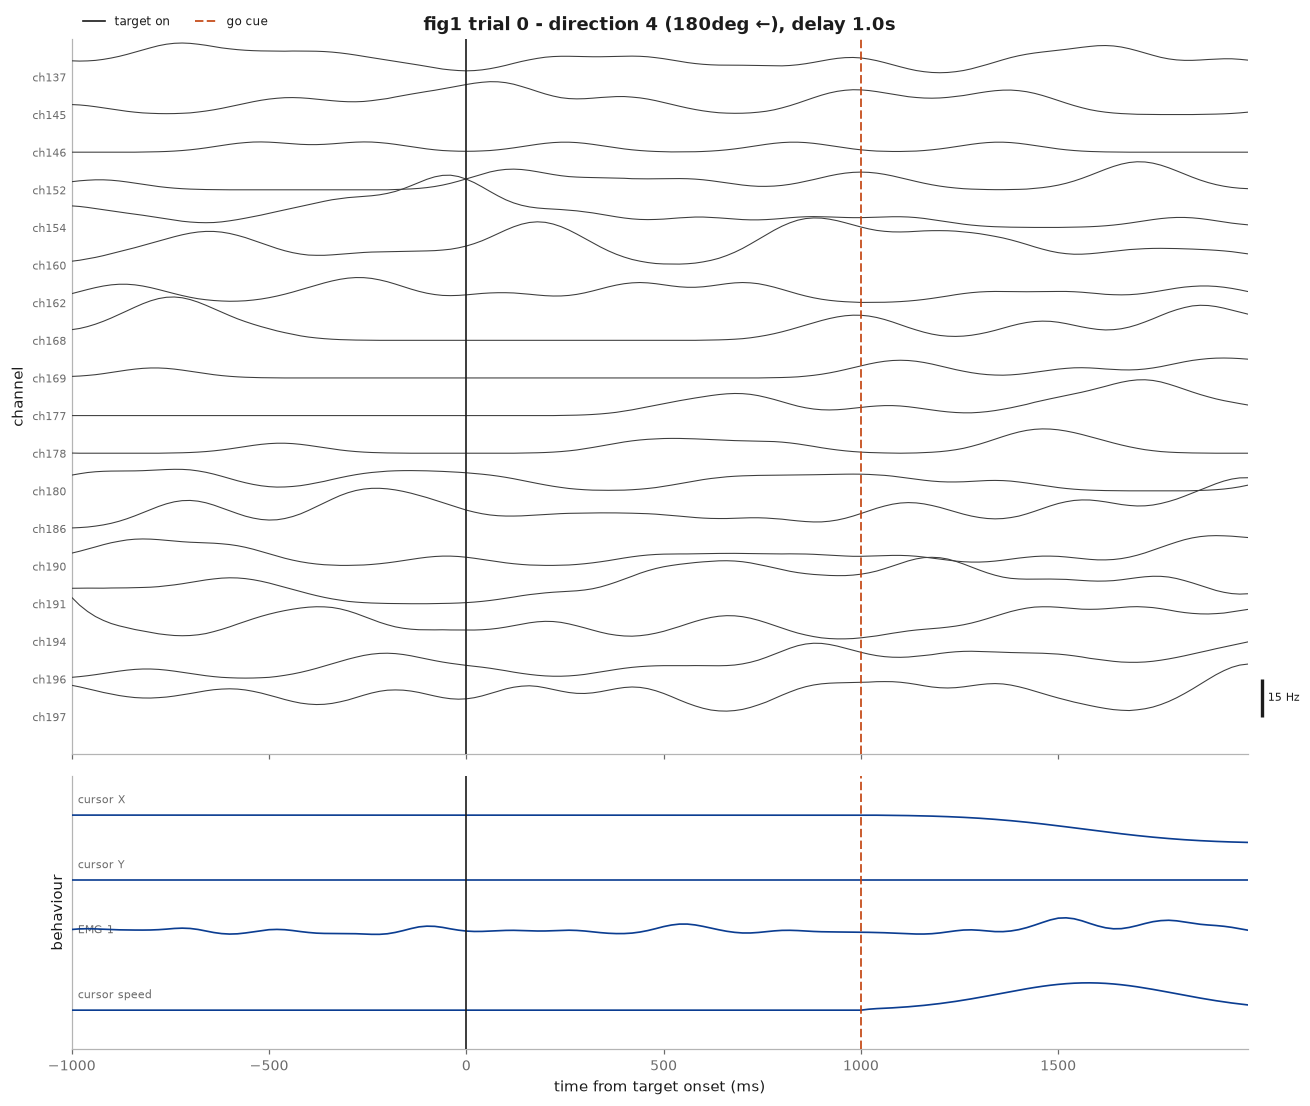

In [10]:
def epoch_aux(trial):
    speed = np.r_[0.0, np.linalg.norm(np.diff(cursor[trial], axis=0), axis=1)] / td.bin_s
    rows = {"cursor X": cursor[trial][:, 0], "cursor Y": cursor[trial][:, 1]}
    if emg is not None:
        rows["EMG 1"] = emg[trial][:, 0]
    rows["cursor speed"] = speed
    return rows

def browse_epoch(trial=0, n_channels=18, scale=15.0):
    d = int(y[trial])
    fig = plotting.plot_epoch_browser(
        td.t_ms, X_hz[trial], ch_labels,
        events={"target on": [0.0], "go cue": [delays_ms[trial]]},
        aux=epoch_aux(trial), n_channels=n_channels, scale=scale, units="Hz",
        title=f"fig1 trial {trial} - direction {d} "
              f"({np.degrees(centres[d]):.0f}deg {plotting.DIRECTION_ARROWS[d]}), "
              f"delay {delays_ms[trial] / 1000:.1f}s",
    )
    return fig

fig = browse_epoch(trial=0)
fig.savefig(config.FIGURES_DIR / "epoch_browser_trial.png", bbox_inches="tight")
plt.show()

> ### The acausal smoothing, visible by eye
>
> Compare these traces with the continuous ones in section 4. The `fig1` traces are
> *dramatically* smoother — they look like gentle waves rather than the spiky activity in
> the fig5 block.
>
> That difference is not physiology. It is the **acausal σ = 100 ms Gaussian kernel**
> applied to the `fig1–4` files (fig5 got causal exponential smoothing instead). Each point
> here is a weighted average over roughly ±200 ms of activity — including the future.
>
> Seeing it is the point. This is why notebook 03 refuses to claim an onset latency: on a
> trace this smooth, "when did it start rising" is a question about the kernel as much as
> about cortex.

Now browse trial by trial.

In [11]:
def show_epoch(trial=0, n_channels=18, scale=15.0):
    browse_epoch(trial=trial, n_channels=n_channels, scale=scale)
    plt.show()

interact(
    show_epoch,
    trial=IntSlider(min=0, max=X_hz.shape[0] - 1, step=1, value=0,
                    description="trial", continuous_update=False),
    n_channels=IntSlider(min=4, max=40, step=2, value=18, description="channels",
                         continuous_update=False),
    scale=FloatSlider(min=2.0, max=60.0, step=2.0, value=15.0, description="scale (Hz)",
                      continuous_update=False),
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='trial', max=263), IntSlider(val…

## 8. Every trial at once: `epochs.plot_image`

A single trial is too noisy to show tuning, and a PSTH averages the trials away. The
erpimage sits between them: **one channel, every trial as a row, colour = firing rate**,
with trials grouped by intended direction.

This is where single-trial structure becomes visible. If a channel is genuinely
direction-tuned, one or two of the eight coloured blocks should visibly brighten after
target onset while the others do not — and you can see how *consistent* that is across
individual trials, which no average will ever tell you.

We pick the channel using notebook 02's saved tuning table, so the choice is by a
pre-registered criterion rather than by eye.

In [12]:
tuning_path = config.TABLES_DIR / "channel_tuning.csv"
if tuning_path.exists():
    tuning = pd.read_csv(tuning_path).sort_values("F_preparatory", ascending=False)
    ranked_electrodes = tuning["electrode"].to_numpy()
    print(f"channel ranking loaded from {tuning_path.name}")
else:
    ranked_electrodes = td.keep_chans.astype(int)
    tuning = None
    print("NOTE: run notebook 02 first to rank channels by tuning; "
          "using file order instead.")

def electrode_to_column(electrode):
    return int(np.where(td.keep_chans.astype(int) == int(electrode))[0][0])

best = int(ranked_electrodes[0])
f_val = (float(tuning.iloc[0]["F_preparatory"]) if tuning is not None else float("nan"))
print(f"most direction-tuned electrode: {best}  (ANOVA F = {f_val:.1f})")

channel ranking loaded from channel_tuning.csv
most direction-tuned electrode: 168  (ANOVA F = 17.1)


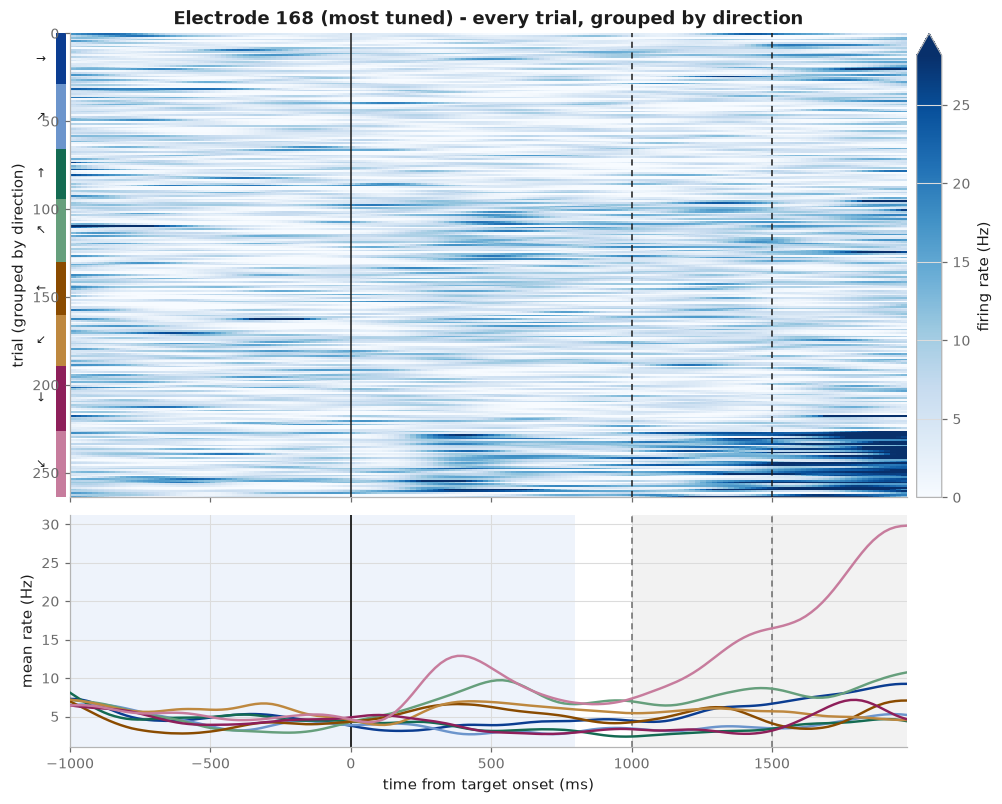

In [13]:
fig = plotting.plot_epochs_image(
    td.t_ms, X_hz[:, :, electrode_to_column(best)], y, centres,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    title=f"Electrode {best} (most tuned) - every trial, grouped by direction",
)
fig.savefig(config.FIGURES_DIR / "epochs_image_channel.png", bbox_inches="tight")
plt.show()

### The control: do the same thing for an untuned channel

A picture that looks structured is only meaningful if the same picture looks unstructured
when there is nothing there. Compare the most-tuned channel above with the least-tuned one.

least direction-tuned electrode: 191  (ANOVA F = 0.1)


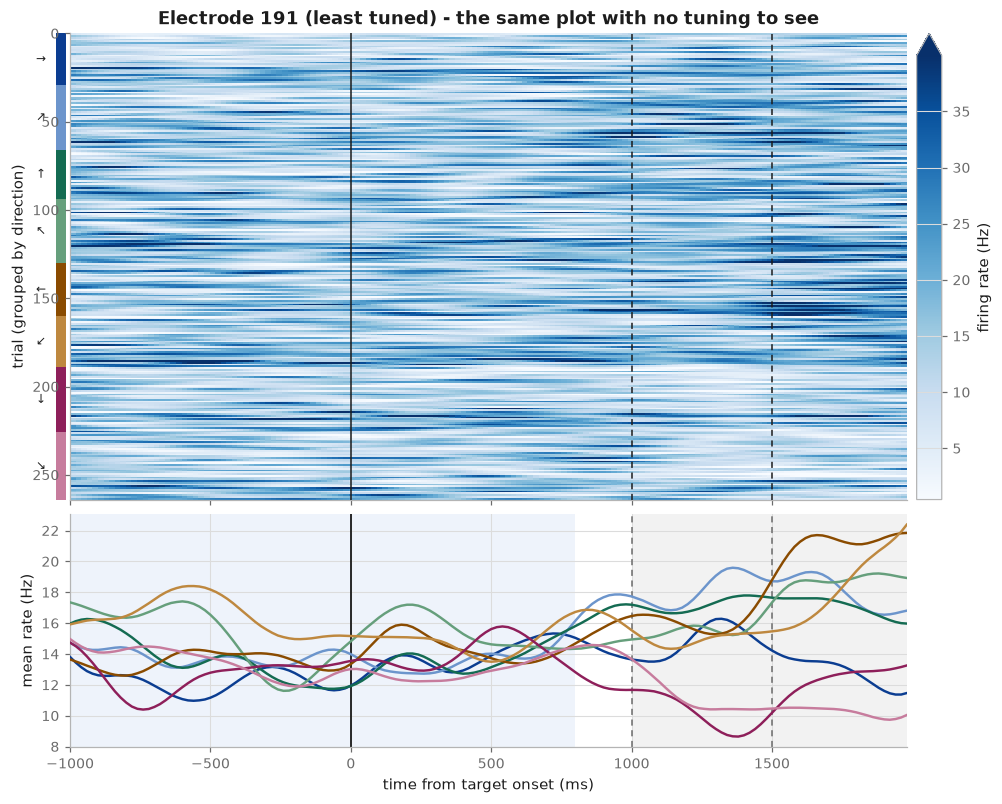

In [14]:
worst = int(ranked_electrodes[-1])
f_worst = (float(tuning.iloc[-1]["F_preparatory"]) if tuning is not None else float("nan"))
print(f"least direction-tuned electrode: {worst}  (ANOVA F = {f_worst:.1f})")

fig = plotting.plot_epochs_image(
    td.t_ms, X_hz[:, :, electrode_to_column(worst)], y, centres,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    title=f"Electrode {worst} (least tuned) - the same plot with no tuning to see",
)
fig.savefig(config.FIGURES_DIR / "epochs_image_untuned.png", bbox_inches="tight")
plt.show()

In [15]:
def show_erpimage(electrode=best):
    fig = plotting.plot_epochs_image(
        td.t_ms, X_hz[:, :, electrode_to_column(electrode)], y, centres,
        go_cue_times_ms=go_cue_times_ms,
        prep_window_ms=config.PREP_WINDOW_MS,
        title=f"Electrode {electrode} - every trial, grouped by direction",
    )
    plt.show()

interact(
    show_erpimage,
    electrode=Dropdown(options=[int(e) for e in ranked_electrodes],
                       value=best, description="electrode"),
);

interactive(children=(Dropdown(description='electrode', options=(168, 236, 186, 251, 203, 154, 145, 197, 137, …

## What this view is for

A checklist of things that only ever turn up by looking, each of which would corrupt a
result silently:

| what you might see | what it would mean |
|---|---|
| flat channels | dead electrodes — must be excluded, or standardisation divides by ~0 |
| a trigger inside or after the movement | broken alignment; every time-resolved result invalid |
| one channel dwarfing the rest | an artefact that will dominate a decoder that has not been standardised |
| slow wander across the block | block-specific drift — the reason folds are grouped by block in notebook 03 |
| traces far smoother than physiology allows | smoothing already applied; no onset-latency claims |
| cursor moving before the go cue | anticipation, or a mislabelled trial |

Nothing in this notebook produces a number that appears in a result. That is the point: it
is the step that tells you whether the numbers in notebooks 02–04 are worth computing.

---

## Now try this

1. **Find the worst channel.** In section 3, sort the live features by SD and browse the
   few with the largest values. Is the biggest-amplitude channel carrying signal, or an
   artefact? Would it dominate a decoder if the features were not standardised?
2. **Does EMG lead or lag the cursor?** Zoom into a single go trial in section 6 and read
   the order of go cue, EMG onset, cursor motion. Roughly how long is each gap, and does
   that match a plausible reaction time?
3. **Browse a no-go trial.** Find one where `no_go_bool == 1` (there are 16) and confirm
   nothing happens after the delay would have ended. Does the *neural* signal look
   different from a go trial in that same window?
4. **Compare the smoothing directly.** Put a fig5 trace and a fig1 trace on the same time
   scale. How much detail did the σ = 100 ms acausal kernel remove — and what would that do
   to an attempt to measure when a channel first responded?
5. **Break the alignment on purpose.** In section 7, pass
   `events={"go cue": [delays_ms[trial] - 400]}` and look at the figure. If you had never
   checked the alignment against the cursor, would you have noticed?